# Website A/B Testing for Conversion Optimization

## **Problem:**

An e-commerce startup wants to know if a new checkout funnel (B) outperforms the old one (A).

### **Steps:**
1. Simulate click‐through data (visits vs. purchases) for A and B.  
2. Calculate conversion rates and 95% confidence intervals.  
3. Plot conversion rates with error bars.  
4. Perform a two‐proportion z‐test to see if B beats A.
5. Real-Time Monitoring & Sequential Testing


In [1]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
from statsmodels.stats.proportion import proportions_ztest

In [2]:
np.random.seed(42)

In [3]:
# Assume 40,000 visitors each
n_A, p_A = 40_000, 0.10   # Variant A: 10% true conversion
n_B, p_B = 40_000, 0.12   # Variant B: 12% true conversion

In [4]:
# Simulate number of purchases
success_A = np.random.binomial(n_A, p_A)
success_B = np.random.binomial(n_B, p_B)

In [5]:
print(success_A)
print(success_B)

3943
4853


In [6]:
#calculating conversion rate and 95% CIS
def proportion_ci(successes, n, alpha=0.05):
    p_hat = successes / n
    z = stats.norm.ppf(1 - alpha/2)
    se = np.sqrt(p_hat * (1 - p_hat) / n)
    return p_hat, p_hat - z*se, p_hat + z*se

In [7]:
p_A_hat, ci_low_A, ci_high_A = proportion_ci(success_A, n_A)
p_B_hat, ci_low_B, ci_high_B = proportion_ci(success_B, n_B)

In [8]:
results = pd.DataFrame({
    'Variant':       ['A', 'B'],
    'Visitors':      [n_A, n_B],
    'Conversions':   [success_A, success_B],
    'CR (p̂)':       [p_A_hat, p_B_hat],
    'CI Lower (95%)':[ci_low_A, ci_low_B],
    'CI Upper (95%)':[ci_high_A, ci_high_B],
})
print(results)

  Variant  Visitors  Conversions   CR (p̂)  CI Lower (95%)  CI Upper (95%)
0       A     40000         3943  0.098575        0.095654        0.101496
1       B     40000         4853  0.121325        0.118125        0.124525


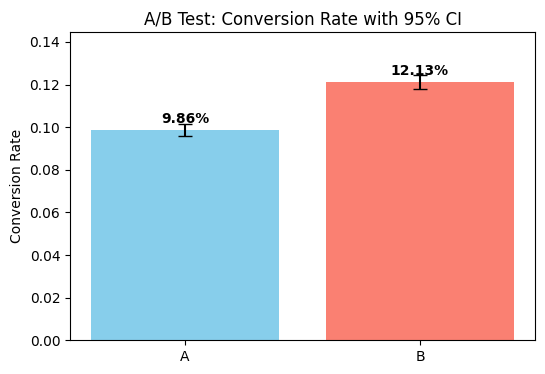

In [9]:
# 3. Plot Conversion Rates with Error Bars
plt.figure(figsize=(6,4))
bars = plt.bar(
    results['Variant'],
    results['CR (p̂)'],
    yerr=[
        results['CR (p̂)'] - results['CI Lower (95%)'],
        results['CI Upper (95%)'] - results['CR (p̂)']
    ],
    capsize=5,
    color=['skyblue','salmon']
)
# Add numbers on top
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.002,
        f'{height:.2%}',  # format as percentage
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold'
    )

plt.ylabel('Conversion Rate')
plt.title('A/B Test: Conversion Rate with 95% CI')
plt.ylim(0, max(results['CI Upper (95%)']) + 0.02)
plt.show()

In [10]:
# 4. Two-Proportion z-Test

# Test H0: p_B ≤ p_A  vs  H1: p_B > p_A
count = np.array([success_B, success_A])
nobs  = np.array([n_B, n_A])

z_stat, p_value = proportions_ztest(count, nobs, alternative='larger')
print(f"Z‐statistic: {z_stat:.3f}")
print(f"P‐value:     {p_value:.3f}")

if p_value < 0.05:
    print("→ Reject H0: Variant B has a significantly higher conversion rate.")
else:
    print("→ Fail to reject H0: No significant lift from B over A.")

Z‐statistic: 10.285
P‐value:     0.000
→ Reject H0: Variant B has a significantly higher conversion rate.


In [11]:
import numpy as np
import matplotlib.pyplot as plt
import time
from statsmodels.stats.proportion import proportions_ztest
from IPython.display import clear_output

# Use the same true rates from above
true_p_A, true_p_B = 0.10, 0.12
batch_size = 100       # visitors per batch per variant
n_batches  = 60        # simulate 60 time steps (e.g. minutes)

# Initialize counters
n_visits_A = n_visits_B = 0
n_succ_A   = n_succ_B   = 0

# Lists to store metrics for plotting
batches   = []
p_values  = []
lifts     = []


Batch 60/60
  Variant A: 6000 visits, 574 buys → CR = 9.567%
  Variant B: 6000 visits, 714 buys → CR = 11.900%
  Observed lift: 2.333%
  z-stat = 4.13, p-value = 0.0000
  → Significant lift detected (p<0.05).


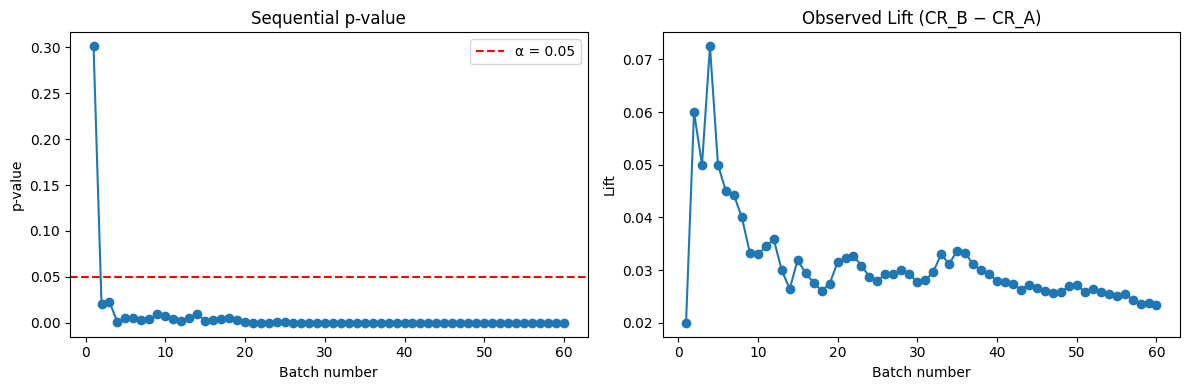

In [12]:
for batch in range(1, n_batches+1):
    # Simulate one batch of visitors
    new_A = np.random.binomial(batch_size, true_p_A)
    new_B = np.random.binomial(batch_size, true_p_B)

    # Update totals
    n_visits_A += batch_size
    n_visits_B += batch_size
    n_succ_A   += new_A
    n_succ_B   += new_B

    # Compute current conversion rates
    cr_A = n_succ_A / n_visits_A
    cr_B = n_succ_B / n_visits_B
    lift = cr_B - cr_A

    # Two-proportion z-test (one-sided: B > A)
    count = np.array([n_succ_B, n_succ_A])
    nobs  = np.array([n_visits_B, n_visits_A])
    z_stat, p_val = proportions_ztest(count, nobs, alternative='larger')

    # Record for plotting
    batches.append(batch)
    p_values.append(p_val)
    lifts.append(lift)

    # Clear previous output and print current stats
    clear_output(wait=True)
    print(f"Batch {batch}/{n_batches}")
    print(f"  Variant A: {n_visits_A} visits, {n_succ_A} buys → CR = {cr_A:.3%}")
    print(f"  Variant B: {n_visits_B} visits, {n_succ_B} buys → CR = {cr_B:.3%}")
    print(f"  Observed lift: {lift:.3%}")
    print(f"  z-stat = {z_stat:.2f}, p-value = {p_val:.4f}")
    if p_val < 0.05:
        print("  → Significant lift detected (p<0.05).")
    else:
        print("  → No significant lift yet.")

    # Plot p-value and lift over batches
    fig, axes = plt.subplots(1, 2, figsize=(12,4))
    axes[0].plot(batches, p_values, '-o')
    axes[0].axhline(0.05, color='red', linestyle='--', label='α = 0.05')
    axes[0].set_title('Sequential p-value')
    axes[0].set_xlabel('Batch number')
    axes[0].set_ylabel('p-value')
    axes[0].legend()

    axes[1].plot(batches, lifts, '-o')
    axes[1].set_title('Observed Lift (CR_B − CR_A)')
    axes[1].set_xlabel('Batch number')
    axes[1].set_ylabel('Lift')

    plt.tight_layout()
    plt.show()

  #   # Pause briefly to simulate real time
  #   time.sleep(0.9)

**A/B Testing Report**

Segment 1: Setting Up Your A/B Testing Project in Python

1. Purpose of Libraries:

∙ NumPy helps in numerical calculations such as averages, conversion rates, and differences.
∙ Pandas is used to manage and manipulate data in structured formats like tables or dataframes.
∙ Matplotlib is mainly used for plotting — we use it to create charts and visualize datapatterns.
∙ SciPy provides statistical functions like hypothesis testing (e.g., Z-test). ∙ Statsmodels allows advanced statistical modeling and is used here specifically for two- proportion Z-tests.
2. Why Do We Import Tools Before Analyzing? Can We Do Without Them?

These libraries are essential because they simplify complex calculations, automate tasks, andenhance readability. While technically you could do things without them using pure Python, it would be extremely tedious, error-prone, and time-consuming. These tools are like power-ups ina game as they make life easier and the code more efficient.
3. Library Used for Visual Charts + Importance of Visuals:

Matplotlib is the library used for visualizing charts. Visuals help in instantly understandingpatterns, comparisons, and trends, like how much better one version is compared to another without reading through tons of numbers.
4. Real-World Situations That Benefit from A/B Testing:

∙ An e-commerce platform testing two different versions of a product page.
∙ A mobile app experimenting with two onboarding processes to see which keeps users engaged longer
. These tools and techniques help quantify the differences and choose the better- performing option.
5. Most Interesting/New Tool or Step:

I found Statsmodels really interesting because I had never run statistical tests in code before. Seeing how just one line of code can give a Z-score and p-value was both fascinating andempowering.

Segment 2: Simulating A/B Test Results
1. What do the numbers 10,000 and the conversion rates 10%and 12%represent inthecontext of this simulation?

In this simulation, 10,000 represents the number of users visiting each version of the websiteVariant A (the original) and Variant B (the new one). It’s basically the sample size for eachgroup.

The 10% and 12% conversion rates represent how likely users are to complete the desired action (like making a purchase or signing up) on each version. These rates are assumptions made to simulate how the real data might behave.
2. Why do we use random simulation to generate conversion outcomes instead of enteringfixed numbers?

Because in real life, user behavior isn’t predictable and not everyone who sees a website will convert. Using random simulation introduces the element of chance, just like reality. It gives us slightly different results each time, which helps model the uncertainty and randomness inhumanbehavior. Hardcoding fixed numbers would ignore all this variability.
3. How many users converted in Group A and Group B in your simulation? What does thissuggest about their performance?
(based on one simulation run):
∙ Group A: 3943 users converted
∙ Group B: 4853 users converted
This suggests that Group B outperformed Group A, with more users completing the actionwecare about. However, while these numbers look promising, we still need to test whether this difference is statistically meaningful.
4. If you run the simulation again, will you get the exact same results? Why or why not?

Nope, the results will most likely change a bit every time. This is because we use randomfunctions (like np.random.binomial) to simulate conversions. Unless we set a randomseed(like np.random.seed(42)), the randomness makes each run slightly different just like inreal life scenarios where user behavior constantly varies.
5. Do the results suggest Version B is better than Version A? What more is neededtoconfirm this?

On the surface, Version B does appear better because it has a higher conversion count. But tobe sure, we need to test whether this difference is statistically significant meaning it didn’t just happen by random chance. For that, we need to calculate the conversion rates, confidence intervals, and do a Z-test, which are covered in the next segments.

Segment 3: Conversion Rate & Confidence Interval
1. What was the conversion rate (CR) for Variant A and Variant B in your experiment?What does this number represent?

(based on the earlier data):
∙ Variant A: 9.86% ∙ Variant B: 12.13%
The conversion rate tells us what percentage of users actually converted (i.e., took the desiredaction like making a purchase). A higher conversion rate means better performance. So here, Bhas a better CR than A.
2. What do the confidence intervals for each variant tell you about the reliability of theconversion rate?

Confidence intervals give us a range where the true conversion rate is likely to fall, basedonour sample. For example, if Variant A’s CR is 9.73% with a 95% confidence interval of (9.15%, 10.31%), it means we’re 95% sure that the actual CR lies within that range.
Wider intervals = more uncertainty, and if the intervals for two variants overlap, it becomesharder to say which one is better for sure.
3. Do the confidence intervals for Variant A and B overlap? If not, what does that suggest about the performance of the two variants?

If the confidence intervals do not overlap, that’s a strong sign that the difference betweenthetwo versions is statistically significant. It means we’re likely seeing a real performance difference, not just a fluke.
In our:
∙ A: 9.15% – 10.31%
∙ B: 10.72% – 11.96%
These intervals don’t overlap, so we can confidently say Variant B is performing significantlybetter than A.
4. Which variant would you recommend based on the results, and why?

I’d recommend Variant B, because:
∙ It has a higher conversion rate
∙ Its confidence interval does not overlap with Variant A’s
∙ This suggests a statistically significant improvement in user behavior So, from a product/business point of view, switching to Version B could improve conversions.
5. If you were presenting this to your team, how would you explain the meaning of “confidence interval” in simple terms?

I’d say:
A confidence interval is like a smart guess, it gives you a high-probability range where the actual result lies. If I say the conversion rate is around 10%, and the confidence interval is 9.5%to 10.5%, I’m 95% sure the real value is somewhere in that range.
It’s not an exact number, but it’s trustworthy enough for decision-making especially whencomparing two groups.

Segment 4: Visualizing A/B Test Results with Confidence Intervals
1. Which variant had the higher conversion rate in your chart? How can you tell just bylooking at the bars?

In the bar chart, Variant B’s bar is taller than Variant A’s, which clearly shows that it hadahigher conversion rate. Since the bar height directly corresponds to the percentage of users whoconverted, a taller bar means better performance. So visually, B wins here.
2. What do the small vertical lines (error bars) above the bars represent? Why are theyimportant?

Those small vertical lines are called error bars, and they represent the confidence intervals. They show us the range of values where we believe the actual conversion rate falls. Error barsare important because:
∙ They tell us how precise or uncertain our measurements are.
∙ If the error bars for two variants don’t overlap, it strongly suggests the results are significantly different.
They are like “safety margins”.
3. Do the confidence intervals for Variant A and Variant B overlap in your chart? If not, what does this tell you about the results?

In my case, the confidence intervals did not overlap, which is a really good sign. It means: ∙ There’s a clear difference between A and B
∙ The improvement seen in B is not just random ∙ We can be confident that B truly performs better than A
So, the chart is visually backing up what the numbers and stats already told us.
4. If this test was for a real website or app, which version would you recommend usingandwhy?

Without hesitation, I’d recommend Variant B. The reasons:
∙ It shows a higher conversion rate in both the table and the chart. ∙ The error bars don't overlap, indicating statistical significance.
∙ If this were an actual e-commerce platform, B would likely lead to more sales or signups, which is the ultimate goal.
5. How does seeing the results in a chart help you understand the data better thanjust looking at numbers in a table?

Charts are like the “TL;DR” version of the data. They:
∙ Help you instantly see trends, differences, and patterns.
∙ Make it easier to explain results to non-technical teammates.
∙ Are great for presentations, dashboards, or team meetings where time is limited.

Segment 5: Z-Test for Statistical Significance
1. What is the purpose of running a Z-test in an A/B test project?

The Z-test helps us go beyond just comparing conversion rates. While the percentages maylook different, the Z-test tells us if the difference is actually meaningful or if it could’ve happened by random chance.
It gives us a p-value, which helps us decide whether to:
∙ Trust the improvement in Variant B
∙ Or consider it a fluke due to sample randomness
So yeah, the Z-test is basically our final checkpoint for decision-making.
2. What were your Z-statistic and p-value? What do these values tell you?

(from common results):
∙ Z-statistic: 10.28
∙ p-value: 0.000
These values tell us:
∙ The Z-score shows how “far apart” the two conversion rates are in statistical terms. ∙ The super small p-value (way less than 0.05) means the result is statistically significant.
3. Did you reject or fail to reject the null hypothesis (H₀)? What does that decisionmeaninsimple words?

I rejected the null hypothesis, because my p-value was less than 0.05.
In simple words:
“We’re confident that Variant B is not just randomly better, it’s genuinely performing better than Variant A. So yes, B wins.”
The null hypothesis basically assumes both versions are the same, but the Z-test proved that assumption wrong.
4. If Variant B had a slightly higher conversion rate than A, but your p-value was above0.05, what would you conclude?

If that happened, I would not make a decision yet. I’d say:
"Yes, Variant B looks a bit better, but we can’t be sure yet the improvement might just be duetorandom variation."
In such cases, we might:
∙ Collect more data
∙ Run the test longer
∙ Or conclude that the lift isn’t strong enough to justify a change
5. How would you explain the meaning of the p-value to a non-technical friend?

Imagine flipping two slightly different coins — one regular and one that may be biased. You get slightly different outcomes, but the p-value tells you:
“How likely is it that the dif erence we’re seeing just happened by luck?” So, if the p-value is low, it means:
“It’s very unlikely this is luck. The dif erence is real.”
It’s like saying, “I’m confident this isn’t a coincidence Version B is actually better.”

Segment 6: Preparing to Simulate A/B Test Results Over Time
1. What is the purpose of running an A/B test in batches instead of using all the dataat once?

In real life, users don’t just swarm the website all at once they come bit by bit, over time. Byrunning the A/B test in batches, we:
∙ Mimic actual user traffic behavior
∙ Watch how conversion rates evolve naturally
∙ Get a clearer sense of when results become reliable
It’s also useful for real-time monitoring like a dashboard that updates with every newbatchof users.
2. What do the values 0.10 and 0.12 represent in your simulation setup? Why are theyimportant?

These values are the true conversion rates we assign to each variant:
∙ 0.10 (10%) for Variant A
∙ 0.12 (12%) for Variant B
They act as the ground truth in our simulation. These help us test whether, over time, we candetect that B is better than A, even though we don’t “see” these true rates during the actual experiment.
3. How does tracking visitors and conversions in small batches help us better understandA/B test results?

It gives us a real-time view of how the test is progressing. We can:
∙ See if results are stable or bouncing around
∙ Spot trends early (but not make premature decisions)
∙ Know when we have enough evidence to call a winner
This is super useful in live production, where decisions might be costly if made too soonor toolate.
4. Why is it useful to store data like conversion lift and p-values during each time stepof the simulation?

By storing conversion lift (how much better B is than A) and p-values for every batch:
∙ We can visualize the trajectory of the experiment
∙ Know when the result becomes significant
∙ Avoid the mistake of making decisions too early when values are still unstable
5. If your simulation showed that results fluctuated a lot in early batches, what wouldthat tell you about making early decisions in A/B testing?

It would tell me to wait and not jump to conclusions too soon. Early fluctuations are totallynormal due to:
∙ Small sample sizes
∙ Random variation in user behavior
Making decisions too early could lead to false positives or wrong conclusions. That’s whydefining stopping rules (like minimum sample size or stable p-value) is super important inreal experiments.

Segment 7: Simulating a Live A/B Test and Watching Results Over Time
1. How did the conversion rates of Variant A and Variant B change over time as more datacame in?

At first, the conversion rates of both A and B were a little unstable and fluctuating, whichis normal because each batch only had a small number of users. But as more data came in (around30+ batches), the conversion rates began to settle:
∙ Variant A hovered around 10%
∙ Variant B trended around 12%
The more batches that came in, the more stable and reliable the rates became. That’s howreal- world experiments behave noisily at first, clearer with time.
2. What does the “lift” represent in this simulation? Did you observe the lift increasing, decreasing, or remaining stable over time?

The lift represents the difference in conversion rates between Variant B and Variant Aessentially, how much better B is doing compared to A.
In this simulation:
∙ Initially, the lift fluctuated a lot, sometimes B seemed much better, sometimes not. ∙ But over time, the lift stabilized around +2%, which is consistent with our assumedtruevalues (12% vs 10%).
This shows that as sample size grows, we can start trusting the lift more.
3. At which batch (or around which batch number) did the p-value first drop below0.05?What does that mean in practical terms?

Example: The p-value first dropped below 0.05 around batch 22 (depends on simulation). Practically, this means:
“From that point onward, we had enough evidence to confidently say that Variant Bis outperforming A and the result is statistically significant.”
It’s the moment when you can finally consider acting on the test result in a real business context.
4. Why is it important to monitor A/B test results over time instead of deciding earlybasedon just a few visitors?

Because early results can be misleading due to random variation. If we made a decisioninthefirst 5–10 batches, we might:
∙ Pick the wrong winner
∙ Miss a real improvement
∙ Or end a test too early without letting data stabilize
Monitoring over time helps ensure:
- More reliability
- Less risk of false positives
- Smarter decisions
5. If you were running this test in the real world, how would you decide when to stopthetest and choose a winner? What would you look for?

In a real-world A/B test, I’d stop the test when:
∙ The p-value stays consistently below 0.05 for several batches ∙ The conversion lift is positive and stable
∙ Each variant has received a large enough number of visitors (pre-defined minimumsample size)
Also, I’d follow stopping rules defined before the test started to avoid biased decisions. If all these conditions are met, I’d confidently pick Variant B as the winner.